### Pipeline de Machine Learning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, r2_score

import os

#crear carpeta para los outputs
os.makedirs("outputs", exist_ok=True)

#Se crea el DF
df = pd.read_csv("sdss_sample.csv")

df.head()

,u,g,r,i,z,redshift,class,snr_r,extinction_r
0,19.363821,19.460918,19.584009,19.456054,19.658009,0.293418,Galaxy,12.992805,0.036178
1,20.290443,20.205250,19.844603,20.338405,20.227140,1.996765,QSO,12.791107,0.053282
2,20.212454,20.470242,20.206240,20.145376,20.248270,2.059417,QSO,11.576403,0.058424
3,19.439586,19.456937,19.670536,19.580546,19.580262,0.090203,Galaxy,12.540911,0.073765
4,19.422419,20.297369,19.789860,19.531545,19.534011,0.540694,Galaxy,15.880706,0.057169


In [ ]:
# Eliminamos columnas no numéricas si existen
df = df.select_dtypes(include=[np.number])

# Eliminamos valores nulos
df = df.dropna()

print(df.shape)

(1000, 8)


### CLASIFICACIÓN (KNN)

In [ ]:
# Suponiendo que existe columna 'class'
# Re-reading the CSV to ensure 'class' column is available
temp_df = pd.read_csv("sdss_sample.csv")

#Aplicamos dropna para tod el dataframe despues de aplit en X y en Y
temp_df = temp_df.dropna()

X = temp_df[['u','g','r','i','z','redshift']]
y = temp_df['class']

# División 70/30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Modelo KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predicción
y_pred = knn.predict(X_test)

# Métricas
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", acc)
print("Matriz de confusión:\n", cm)

Accuracy: 0.9933333333333333
Matriz de confusión:
 [[106   0   0]
 [  2  84   0]
 [  0   0 108]]


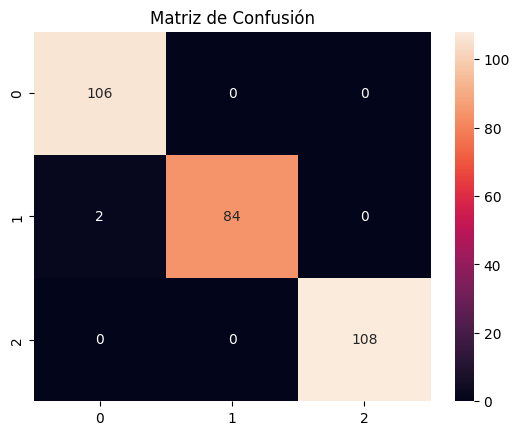

In [ ]:
#cuardar matriz de confusión
import seaborn as sns

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Matriz de Confusión")
plt.show()
plt.savefig("outputs/confusion_matrix.png")
plt.close()

### Regresión

In [ ]:
X_reg = df[['u','g','r','i','z']]
y_reg = df['redshift']

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.3)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Métricas
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)

MSE: 0.3084029119843941
R2: 0.49274965661691916


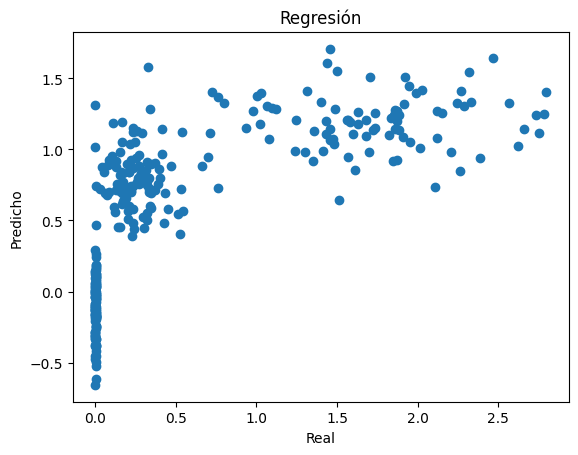

In [ ]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Regresión")
plt.show()
plt.savefig("outputs/regression_plot.png")
plt.close()

### CLUSTERING (KMeans)

In [ ]:
X_cluster = df[['u','g','r','i','z']]

kmeans = KMeans(n_clusters=3)
clusters = kmeans.fit_predict(X_cluster)

df['cluster'] = clusters

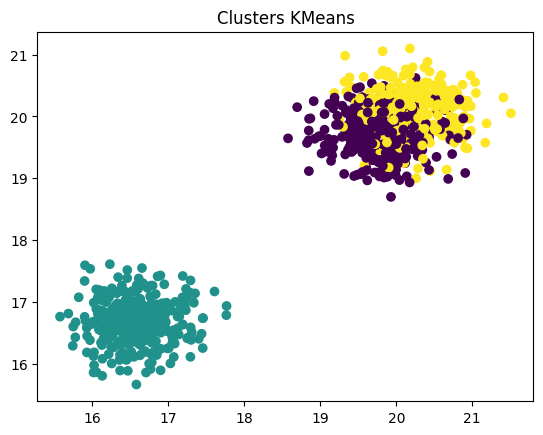

In [ ]:
plt.figure()
plt.scatter(df['u'], df['g'], c=clusters)
plt.title("Clusters KMeans")
plt.show()
plt.savefig("outputs/clusters.png")
plt.close()